In [16]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

### Scenario 1

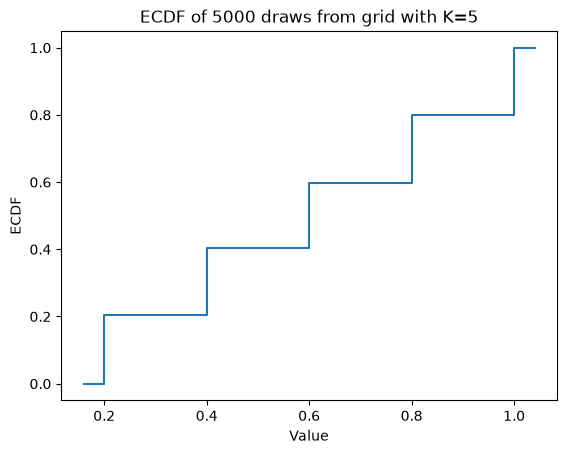

In [5]:
K = 5
n = 5000

grid = np.arange(1, K + 1)/K
draws = np.random.choice(grid, size=n)

ecdf = stats.ecdf(draws)

ecdf.cdf.plot()
plt.xlabel("Value")
plt.ylabel("ECDF")
plt.title(f"ECDF of {n} draws from grid with K={K}")
plt.show()

This simulation appraoches a uniform distribution as K increases. Each value between 0 and 1 has the same liklihood of being selected, which is why the axes matchup here. 

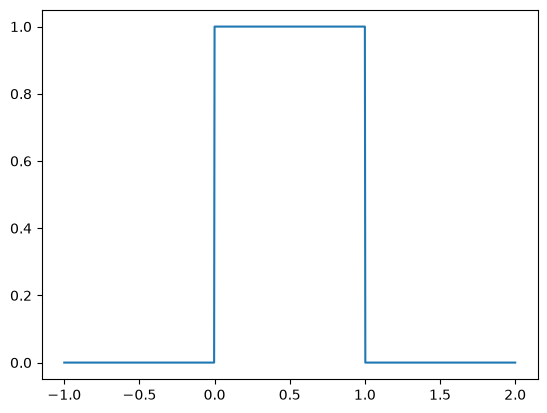

In [23]:
a = 0
b = 1
x = np.linspace(a - 1, b + 1, 1000)
pdf_values = stats.uniform.pdf(x, loc=a, scale=b-a)

plt.plot(x, pdf_values)

### Scenario 3

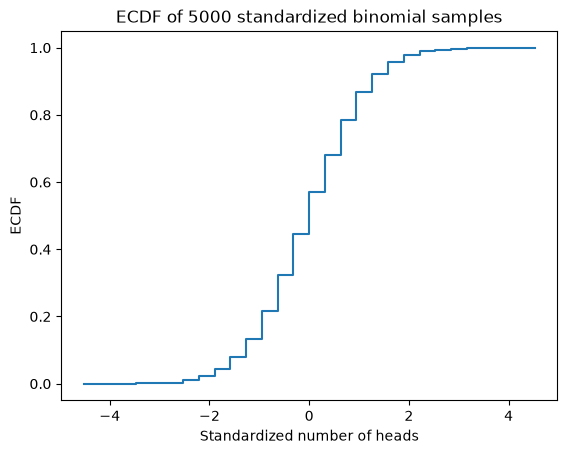

In [7]:
n = 40
p = .5
b = 5000

expectation = n * p
sd = np.sqrt( n * p * (1-p) )

values = []

for i in range(b):
    heads = np.random.binomial(n, p)
    vals = (heads - expectation) / sd

    values.append(vals)


ecdf = stats.ecdf(values)

ecdf.cdf.plot()
plt.xlabel("Standardized number of heads")
plt.ylabel("ECDF")
plt.title(f"ECDF of {b} standardized binomial samples")
plt.show()


Because we are standardizing the result by subtracting the expecation and dividing by the standard deviation, this distribution will appraoch the standard normal distribution. You can see that the mean appears to be 0 on the ECDF graph. 

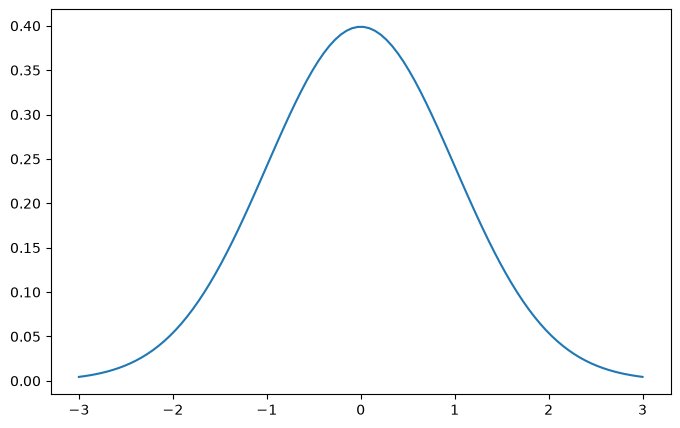

In [26]:
mu = 0
sigma = 1

x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)

y = stats.norm.pdf(x, mu, sigma)

# 4. Plot the curve
plt.figure(figsize=(8, 5))
plt.plot(x, y)

##### Changing p

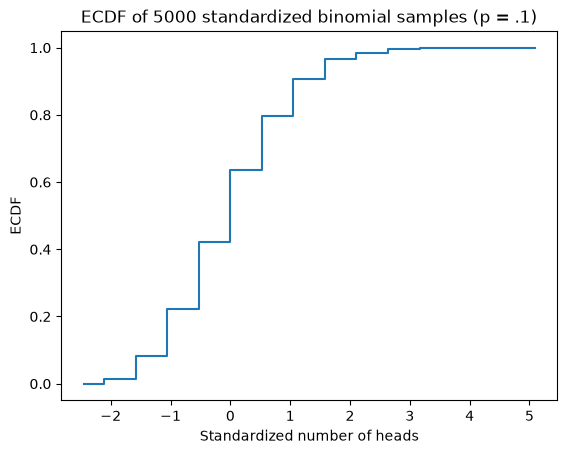

In [8]:
n = 40
p = .1
b = 5000

expectation = n * p
sd = np.sqrt( n * p * (1-p) )

values = []

for i in range(b):
    heads = np.random.binomial(n, p)
    vals = (heads - expectation) / sd

    values.append(vals)


ecdf = stats.ecdf(values)

ecdf.cdf.plot()
plt.xlabel("Standardized number of heads")
plt.ylabel("ECDF")
plt.title(f"ECDF of {b} standardized binomial samples (p = .1)")
plt.show()

Because p is now .1, our expectation changes from 20 to 4. The distribution will still approach a normal distribution with a mean of 0, but the data will look more skewed at a smaller value of n.

### Scenario 5

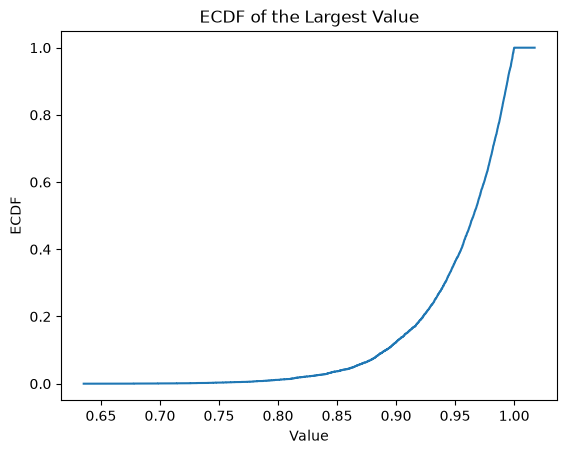

In [13]:
K = 20
n = 5000

# Value store: one list for top ranks, and one for loop to store 20
rank_values = [[] for _ in range(K)]

for i in range(n):
    # Draw values from Uniform
    draws = np.random.uniform(0, 1, K)

    sorted_draws = np.sort(draws)

    # Record rank
    for rank in range(K):
        rank_values[rank].append(sorted_draws[rank])


# Largest = last: rank 20
ecdf = stats.ecdf(rank_values[19])

ecdf.cdf.plot()
plt.xlabel("Value")
plt.ylabel("ECDF")
plt.title("ECDF of the Largest Value")
plt.show()